# Logistic Regression for Conspiracy Detection
## Predicting conspiracy labels (yes/no/cant_tell)

This notebook implements Logistic Regression classifier for:
1. **Conspiracy Label Prediction**: yes/no/cant_tell (multiclass classification)
2. **Model Evaluation**: 5-fold cross-validation on training set
3. **Validation Set Testing**: Evaluation on held-out validation set (100 samples)


In [11]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")


Libraries imported successfully!


In [12]:
# Load and merge all features
BASE = Path('../')
PROC = BASE / 'data_processed'
FEAT = BASE / 'features'

# Load base data from data_clean.csv (contains _id, text, conspiracy)
df = pd.read_csv(PROC / 'data_clean.csv')

print(f"Base data: {df.shape}")
print(f"Base columns: {list(df.columns)}")
print(f"Base data row count: {len(df)}")

# Preserve original columns from data_clean.csv
base_cols = ['_id', 'text', 'conspiracy']
for col in base_cols:
    if col not in df.columns:
        print(f"WARNING: {col} not found in base data!")

# Store base _id values to ensure we only keep these rows
base_ids = set(df['_id'].values)
print(f"Unique _id values in base: {len(base_ids)}")

# Load feature files
feature_files = [
    FEAT / 'lexical_complexity.csv',
    FEAT / 'discourse_markers.csv',
    FEAT / 'sentiment_emotion.csv',
    FEAT / 'token_pos_counts.csv',
    FEAT / 'readability_scores.csv',
    FEAT / 'ma_ttr_mtld_scores.csv',
    FEAT / 'pos_analysis.csv'
]

# Start with base data - this preserves _id, text, conspiracy from data_clean.csv
merged = df.copy()
initial_row_count = len(merged)

# Merge feature files, ensuring we keep original columns from data_clean.csv
# and preserve the exact row count from base data
for feat_file in feature_files:
    if feat_file.exists():
        try:
            feat_df = pd.read_csv(feat_file)
            print(f"\nLoading {feat_file.name}: {feat_df.shape[0]} rows, {feat_df.shape[1]} columns")
            
            if '_id' in merged.columns and '_id' in feat_df.columns:
                # Filter feature file to only include rows with _id in base data
                feat_df_filtered = feat_df[feat_df['_id'].isin(base_ids)].copy()
                print(f"  Filtered to {len(feat_df_filtered)} rows matching base _id values")
                
                # Remove duplicates by _id (keep first occurrence) to prevent row explosion
                initial_filtered_count = len(feat_df_filtered)
                feat_df_filtered = feat_df_filtered.drop_duplicates(subset=['_id'], keep='first')
                if len(feat_df_filtered) < initial_filtered_count:
                    print(f"  Removed {initial_filtered_count - len(feat_df_filtered)} duplicate _id rows (kept first)")
                
                # Drop any columns from feature file that conflict with base_cols (except _id)
                cols_to_drop = [col for col in feat_df_filtered.columns if col in base_cols and col != '_id']
                if cols_to_drop:
                    feat_df_filtered = feat_df_filtered.drop(columns=cols_to_drop)
                    print(f"  Dropped conflicting columns: {cols_to_drop}")
                
                # Merge on _id, keeping all rows from merged (left join)
                merged = merged.merge(feat_df_filtered, on='_id', how='left')
                print(f"  Merged successfully. Merged shape: {merged.shape}")
            else:
                print(f"  Skipped: missing '_id' column")
        except Exception as e:
            print(f"Could not load {feat_file.name}: {e}")

# Verify that original columns from data_clean.csv are still present
for col in base_cols:
    if col not in merged.columns:
        print(f"ERROR: {col} was lost during merge!")

# Verify row count is preserved
if len(merged) != initial_row_count:
    print(f"\nWARNING: Row count changed from {initial_row_count} to {len(merged)}!")
else:
    print(f"\n✓ Row count preserved: {initial_row_count}")

print(f"\nFinal merged shape: {merged.shape}")
print(f"Total columns: {len(merged.columns)}")
print(f"Original columns preserved: {all(col in merged.columns for col in base_cols)}")
print(f"\nColumn breakdown:")
print(f"  Base columns: {base_cols}")
print(f"  Feature columns added: {len(merged.columns) - len(base_cols)}")
print(f"\nFirst few rows (showing base columns + first 5 feature columns):")
feature_cols = [col for col in merged.columns if col not in base_cols][:5]
print(merged[base_cols + feature_cols].head())


Base data: (3682, 3)
Base columns: ['_id', 'text', 'conspiracy']
Base data row count: 3682
Unique _id values in base: 3682

Loading lexical_complexity.csv: 3682 rows, 5 columns
  Filtered to 3682 rows matching base _id values
  Merged successfully. Merged shape: (3682, 7)

Loading discourse_markers.csv: 3682 rows, 5 columns
  Filtered to 3682 rows matching base _id values
  Merged successfully. Merged shape: (3682, 11)

Loading sentiment_emotion.csv: 3682 rows, 13 columns
  Filtered to 3682 rows matching base _id values
  Merged successfully. Merged shape: (3682, 23)

Loading token_pos_counts.csv: 3682 rows, 8 columns
  Filtered to 3682 rows matching base _id values
  Merged successfully. Merged shape: (3682, 30)

Loading readability_scores.csv: 4316 rows, 7 columns
  Filtered to 4316 rows matching base _id values
  Removed 634 duplicate _id rows (kept first)
  Merged successfully. Merged shape: (3682, 36)

Loading ma_ttr_mtld_scores.csv: 3682 rows, 3 columns
  Filtered to 3682 rows ma

In [13]:
# Create validation set (100 randomly selected points)
# This validation set will be saved and reused across all ML notebooks
from sklearn.model_selection import train_test_split

VALIDATION_SIZE = 100
VALIDATION_FILE = PROC / 'validation_set_ids.csv'

# Set random seed for reproducibility
np.random.seed(42)

# Check if validation set already exists
if VALIDATION_FILE.exists():
    print("Loading existing validation set...")
    validation_ids_df = pd.read_csv(VALIDATION_FILE)
    validation_ids = set(validation_ids_df['_id'].values)
    print(f"  Loaded {len(validation_ids)} validation IDs from {VALIDATION_FILE.name}")
else:
    print(f"Creating new validation set ({VALIDATION_SIZE} samples)...")
    
    # Use stratified sampling to maintain class distribution
    label_counts = merged['conspiracy'].value_counts()
    print(f"  Class distribution: {dict(label_counts)}")
    
    target_fraction = VALIDATION_SIZE / len(merged)
    
    # Perform stratified split
    train_ids, val_ids = train_test_split(
        merged['_id'].values,
        test_size=target_fraction,
        stratify=merged['conspiracy'].values,
        random_state=42
    )
    
    # Adjust to exactly 100 if needed
    if len(val_ids) > VALIDATION_SIZE:
        val_df_temp = merged[merged['_id'].isin(val_ids)]
        val_ids_adjusted, _ = train_test_split(
            val_ids,
            test_size=VALIDATION_SIZE / len(val_ids),
            stratify=val_df_temp['conspiracy'].values,
            random_state=42
        )
        validation_ids = set(val_ids_adjusted)
    elif len(val_ids) < VALIDATION_SIZE:
        train_df_temp = merged[merged['_id'].isin(train_ids)]
        additional_needed = VALIDATION_SIZE - len(val_ids)
        additional_ids, _ = train_test_split(
            train_ids,
            test_size=additional_needed / len(train_ids),
            stratify=train_df_temp['conspiracy'].values,
            random_state=42
        )
        validation_ids = set(list(val_ids) + list(additional_ids))
    else:
        validation_ids = set(val_ids)
    
    # Save validation set IDs
    validation_ids_df = pd.DataFrame({'_id': list(validation_ids)})
    validation_ids_df.to_csv(VALIDATION_FILE, index=False)
    print(f"  ✓ Saved validation set to {VALIDATION_FILE.name}")
    print(f"  Validation set size: {len(validation_ids)} samples")

# Display validation set distribution
validation_df = merged[merged['_id'].isin(validation_ids)]
print(f"\nValidation set class distribution:")
print(validation_df['conspiracy'].value_counts().to_dict())

# Remove validation set from training data
train_df = merged[~merged['_id'].isin(validation_ids)].copy()
print(f"\nTraining set size: {len(train_df)} samples")
print(f"Training set class distribution:")
print(train_df['conspiracy'].value_counts().to_dict())

# Update merged to be training data only
merged = train_df.copy()
print(f"\n✓ Updated merged dataframe for training: {merged.shape}")


Loading existing validation set...
  Loaded 100 validation IDs from validation_set_ids.csv

Validation set class distribution:
{'no': 46, 'yes': 36, 'cant_tell': 18}

Training set size: 3582 samples
Training set class distribution:
{'no': 1662, 'yes': 1267, 'cant_tell': 653}

✓ Updated merged dataframe for training: (3582, 73)


In [14]:
# Extract numeric features
numeric_cols = merged.select_dtypes(include=[np.number]).columns.tolist()
# Remove _id and other non-feature columns
numeric_cols = [c for c in numeric_cols if c not in ['_id']]
print(f"Number of numeric features: {len(numeric_cols)}")

X = merged[numeric_cols].fillna(0)
print(X.head())
print(f"Feature matrix shape: {X.shape}")
print(f"Missing values: {X.isna().sum().sum()}")


Number of numeric features: 70
        ttr  hapax_ratio  avg_word_len  shannon_entropy  hedge_count  \
0  0.857143     0.714286      4.678571         4.521641            0   
1  0.779221     0.675325      4.870130         5.665947            0   
2  0.761905     0.587302      4.920635         5.431811            0   
3  0.842105     0.736842      4.736842         5.468769            0   
4  0.707071     0.575758      4.898990         5.807761            0   

   certainty_count  discourse_count  passive_count    neg    neu  ...  \
0                0                0              0  0.000  0.799  ...   
1                0                0              1  0.072  0.874  ...   
2                0                0              1  0.034  0.908  ...   
3                0                0              0  0.171  0.693  ...   
4                1                0              1  0.000  0.857  ...   

   adp_ratio  cconj_ratio  sconj_ratio  num_ratio  part_ratio  intj_ratio  \
0   0.166667     0.0

## Task 1: Conspiracy Label Prediction (yes/no/cant_tell)


In [15]:
# Task 1: Conspiracy Label Prediction (yes/no/cant_tell)
y_conspiracy = merged['conspiracy'].copy()
# Filter out any null labels
mask = y_conspiracy.notna()
X_clean = X[mask]
y_clean = y_conspiracy[mask]

print(f"Samples for conspiracy prediction: {len(y_clean)}")
print(f"Label distribution:")
print(y_clean.value_counts())

# Encode labels
le_conspiracy = LabelEncoder()
y_encoded = le_conspiracy.fit_transform(y_clean)
print(f"Encoded labels: {dict(zip(le_conspiracy.classes_, range(len(le_conspiracy.classes_))))}")

# Create pipeline with scaling and Logistic Regression
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(multi_class='multinomial', solver='lbfgs', 
                              max_iter=1000, C=1.0, random_state=42))
])

# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['accuracy', 'f1_macro', 'f1_weighted', 'precision_macro', 'recall_macro']
cv_results = cross_validate(pipeline, X_clean, y_encoded, cv=cv, scoring=scoring, n_jobs=-1)

print("\n=== Conspiracy Label Prediction (5-fold CV) ===")
for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"{metric}: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

# Train final model
pipeline.fit(X_clean, y_encoded)
print("\nModel trained successfully!")

lr_model = pipeline.named_steps['lr']

# Get feature coefficients (for multiclass, average absolute coefficients)
if hasattr(lr_model, 'coef_'):
    avg_coef = np.abs(lr_model.coef_).mean(axis=0)
    feature_coef = pd.DataFrame({
        'feature': numeric_cols,
        'avg_abs_coefficient': avg_coef
    }).sort_values('avg_abs_coefficient', ascending=False)
    
    print("\nTop 20 Most Important Features (by coefficient magnitude):")
    print(feature_coef.head(20))


Samples for conspiracy prediction: 3582
Label distribution:
conspiracy
no           1662
yes          1267
cant_tell     653
Name: count, dtype: int64
Encoded labels: {'cant_tell': 0, 'no': 1, 'yes': 2}



=== Conspiracy Label Prediction (5-fold CV) ===
accuracy: 0.4774 (+/- 0.0133)
f1_macro: 0.3445 (+/- 0.0160)
f1_weighted: 0.4257 (+/- 0.0126)
precision_macro: 0.3879 (+/- 0.0542)
recall_macro: 0.3769 (+/- 0.0109)

Model trained successfully!

Top 20 Most Important Features (by coefficient magnitude):
                 feature  avg_abs_coefficient
23               n_verbs             0.320612
38                n_verb             0.249236
0                    ttr             0.209291
28  flesch_kincaid_grade             0.207614
31                   ari             0.201570
1            hapax_ratio             0.194828
3        shannon_entropy             0.192571
41                n_pron             0.163331
27   flesch_reading_ease             0.153908
36                n_noun             0.146761
44               n_cconj             0.145826
25                n_advs             0.121835
20            n_tokens_x             0.111222
2           avg_word_len             0.105734
46      

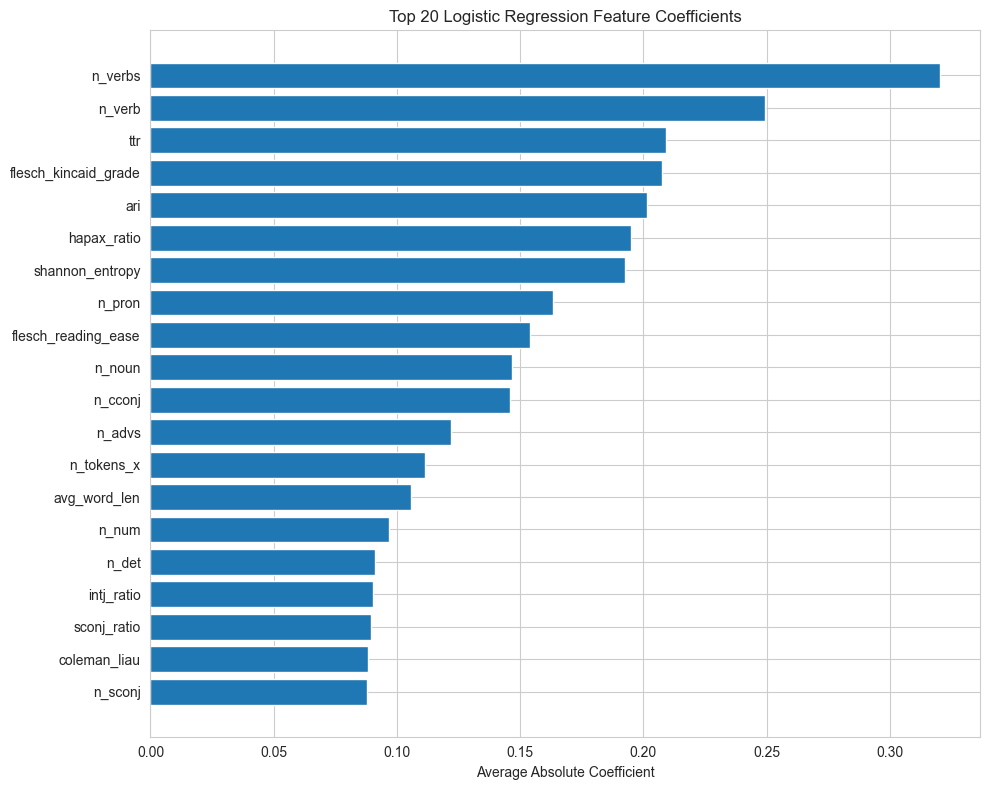


✓ Saved feature coefficients plot to figures/logistic_regression_feature_coefficients.png


In [16]:
# Visualize feature coefficients
if hasattr(lr_model, 'coef_'):
    plt.figure(figsize=(10, 8))
    top_features = feature_coef.head(20)
    plt.barh(range(len(top_features)), top_features['avg_abs_coefficient'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Average Absolute Coefficient')
    plt.title('Top 20 Logistic Regression Feature Coefficients')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(BASE / 'figures' / 'logistic_regression_feature_coefficients.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✓ Saved feature coefficients plot to figures/logistic_regression_feature_coefficients.png")


## Testing on Validation Set

Evaluate the trained model on the held-out validation set (100 samples).


In [17]:
# Load validation set
validation_ids_df = pd.read_csv(VALIDATION_FILE)
validation_ids = set(validation_ids_df['_id'].values)

# Get validation set data from the original merged dataframe (before splitting)
# We need to reload the full dataset to get validation samples
df_full = pd.read_csv(PROC / 'data_clean.csv')

# Merge features for validation set
validation_df_base = df_full[df_full['_id'].isin(validation_ids)].copy()
print(f"Validation set base size: {len(validation_df_base)}")

# Merge all features for validation set (same as training data)
validation_merged = validation_df_base.copy()

# Load and merge feature files for validation set
for feat_file in feature_files:
    if feat_file.exists():
        try:
            feat_df = pd.read_csv(feat_file)
            if '_id' in validation_merged.columns and '_id' in feat_df.columns:
                feat_df_filtered = feat_df[feat_df['_id'].isin(validation_ids)].copy()
                # Remove duplicates
                feat_df_filtered = feat_df_filtered.drop_duplicates(subset=['_id'], keep='first')
                # Drop conflicting columns
                cols_to_drop = [col for col in feat_df_filtered.columns if col in base_cols and col != '_id']
                if cols_to_drop:
                    feat_df_filtered = feat_df_filtered.drop(columns=cols_to_drop)
                validation_merged = validation_merged.merge(feat_df_filtered, on='_id', how='left')
        except Exception as e:
            print(f"Could not load {feat_file.name} for validation: {e}")

print(f"Validation set with features: {validation_merged.shape}")
print(f"Validation set class distribution:")
print(validation_merged['conspiracy'].value_counts())

# Prepare validation features
X_val = validation_merged[numeric_cols].fillna(0)
y_val = validation_merged['conspiracy'].copy()

# Encode validation labels using the same encoder
y_val_encoded = le_conspiracy.transform(y_val)

print(f"\nValidation set feature matrix: {X_val.shape}")
print(f"Validation set labels: {len(y_val)}")


Validation set base size: 100
Validation set with features: (100, 73)
Validation set class distribution:
conspiracy
no           46
yes          36
cant_tell    18
Name: count, dtype: int64

Validation set feature matrix: (100, 70)
Validation set labels: 100


=== Validation Set Predictions ===

True label distribution:
{'no': 46, 'yes': 36, 'cant_tell': 18}

Predicted label distribution:
{'no': 66, 'yes': 34}

=== Validation Set Performance ===
Accuracy: 0.4600
F1 (macro): 0.3238
F1 (weighted): 0.4069

=== Detailed Classification Report ===
              precision    recall  f1-score   support

   cant_tell       0.00      0.00      0.00        18
          no       0.48      0.70      0.57        46
         yes       0.41      0.39      0.40        36

    accuracy                           0.46       100
   macro avg       0.30      0.36      0.32       100
weighted avg       0.37      0.46      0.41       100


=== Confusion Matrix ===
Rows = True labels, Columns = Predicted labels
Label order: ['cant_tell', 'no', 'yes']
[[ 0 12  6]
 [ 0 32 14]
 [ 0 22 14]]


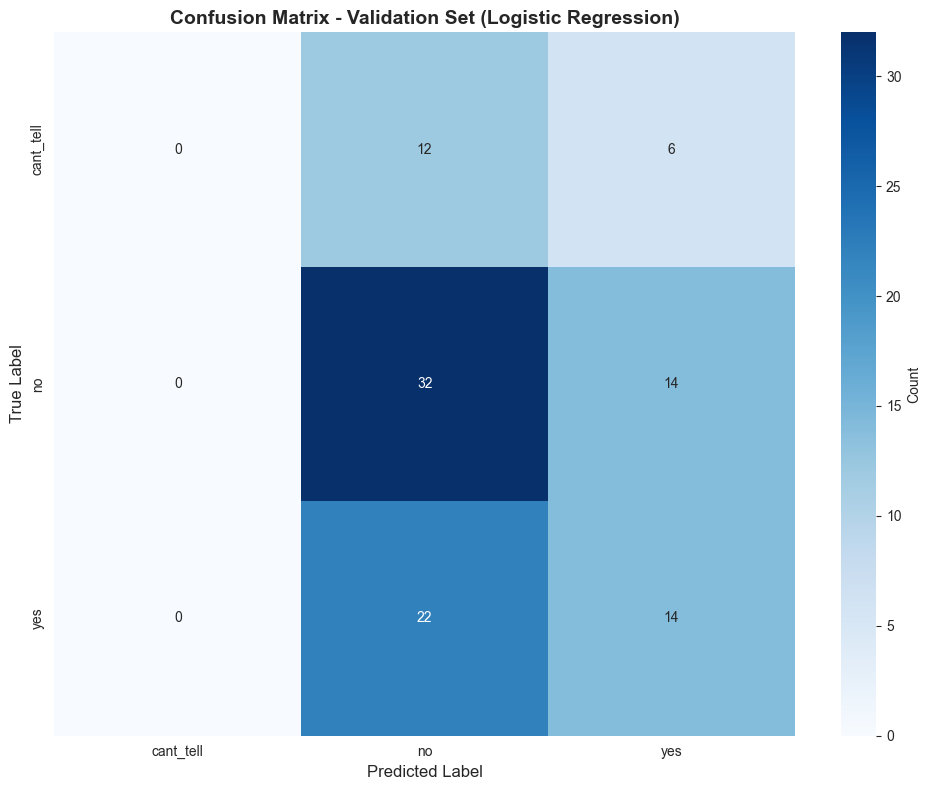


✓ Saved confusion matrix to figures/validation_confusion_matrix_lr.png


In [18]:
# Make predictions on validation set
y_val_pred = pipeline.predict(X_val)
y_val_pred_labels = le_conspiracy.inverse_transform(y_val_pred)

print("=== Validation Set Predictions ===")
print(f"\nTrue label distribution:")
print(y_val.value_counts().to_dict())

print(f"\nPredicted label distribution:")
unique, counts = np.unique(y_val_pred_labels, return_counts=True)
print(dict(zip(unique, counts)))

# Calculate metrics
val_accuracy = accuracy_score(y_val_encoded, y_val_pred)
val_f1_macro = f1_score(y_val_encoded, y_val_pred, average='macro')
val_f1_weighted = f1_score(y_val_encoded, y_val_pred, average='weighted')

print(f"\n=== Validation Set Performance ===")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"F1 (macro): {val_f1_macro:.4f}")
print(f"F1 (weighted): {val_f1_weighted:.4f}")

# Detailed classification report
print(f"\n=== Detailed Classification Report ===")
print(classification_report(y_val, y_val_pred_labels, target_names=le_conspiracy.classes_))

# Confusion matrix
cm = confusion_matrix(y_val_encoded, y_val_pred)
print(f"\n=== Confusion Matrix ===")
print("Rows = True labels, Columns = Predicted labels")
print(f"Label order: {list(le_conspiracy.classes_)}")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_conspiracy.classes_, 
            yticklabels=le_conspiracy.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Validation Set (Logistic Regression)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(BASE / 'figures' / 'validation_confusion_matrix_lr.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved confusion matrix to figures/validation_confusion_matrix_lr.png")


In [19]:
# Compare predictions with true labels for some examples
print("\n=== Sample Predictions ===")
sample_indices = np.random.choice(len(validation_merged), size=min(10, len(validation_merged)), replace=False)

results_df = pd.DataFrame({
    '_id': validation_merged.iloc[sample_indices]['_id'].values,
    'true_label': y_val.iloc[sample_indices].values,
    'predicted_label': y_val_pred_labels[sample_indices],
    'correct': (y_val.iloc[sample_indices].values == y_val_pred_labels[sample_indices])
})

print(results_df.to_string(index=False))

print(f"\n✓ Validation set evaluation complete!")
print(f"  Total validation samples: {len(validation_merged)}")
print(f"  Accuracy: {val_accuracy:.4f}")
print(f"  Correct predictions: {(y_val.values == y_val_pred_labels).sum()}/{len(y_val)}")



=== Sample Predictions ===
       _id true_label predicted_label  correct
t1_dyp3e6m         no             yes    False
t1_kd9reh7        yes             yes     True
t1_ey1cjd2  cant_tell              no    False
t1_iv7fmry        yes             yes     True
t1_jyv5s36         no              no     True
t1_et51gb7         no              no     True
t1_iai3vcu         no              no     True
t1_d01kd3o        yes              no    False
t1_h9sxlpx        yes              no    False
t1_elc14lm         no             yes    False

✓ Validation set evaluation complete!
  Total validation samples: 100
  Accuracy: 0.4600
  Correct predictions: 46/100
